importing librarys

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ahmedmahmoudelmer1/carprice/CarPrice_Assignment.csv


In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("/kaggle/input/datasets/ahmedmahmoudelmer1/carprice/CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [16]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

# EDA

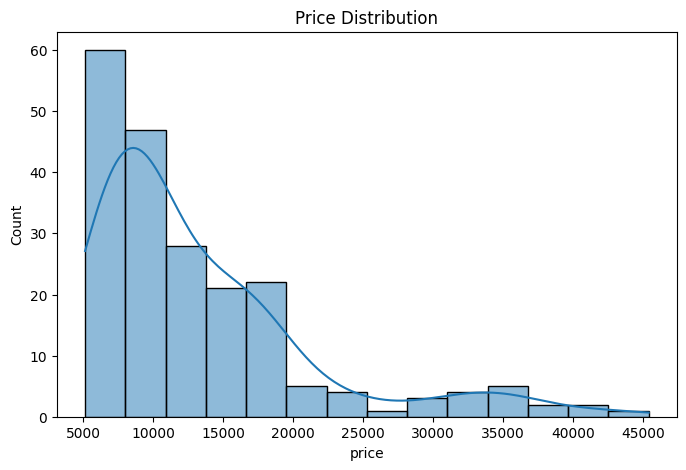

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Price Distribution")

plt.show()

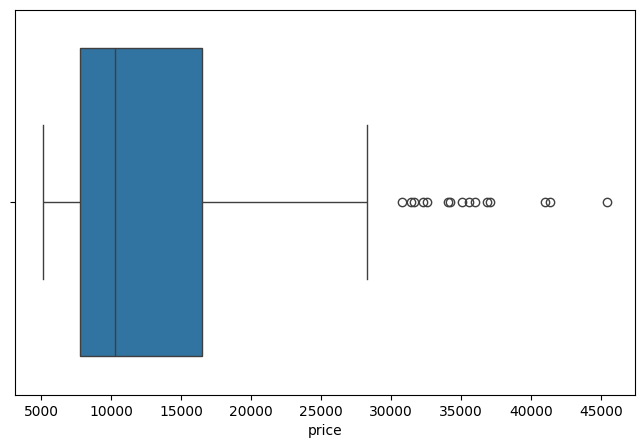

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.show()

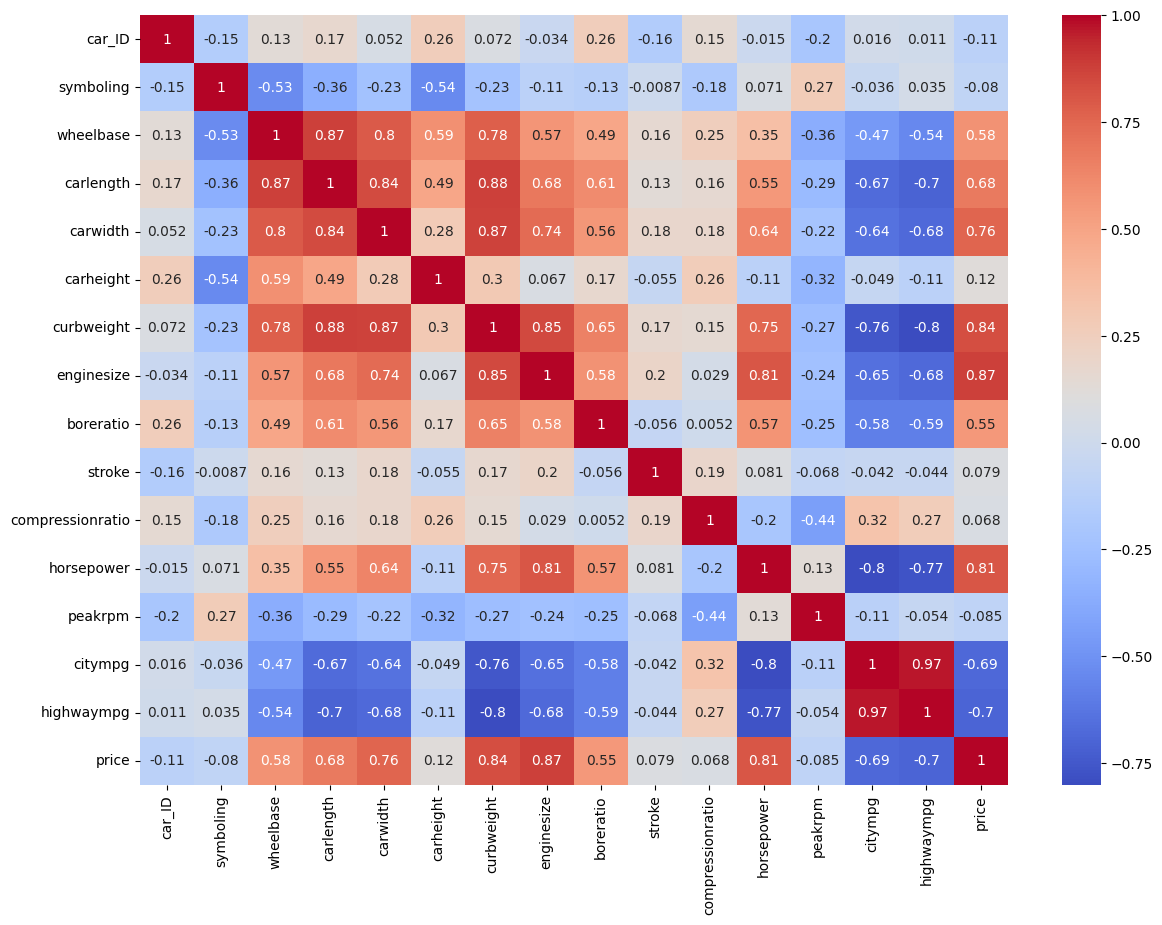

In [9]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()

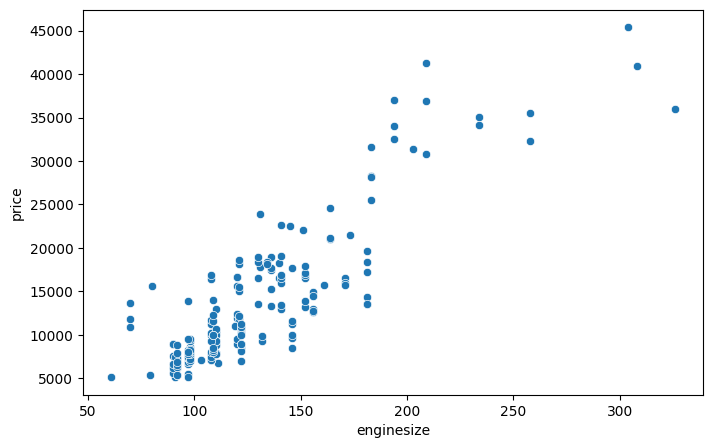

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['enginesize'], y=df['price'])

plt.show()

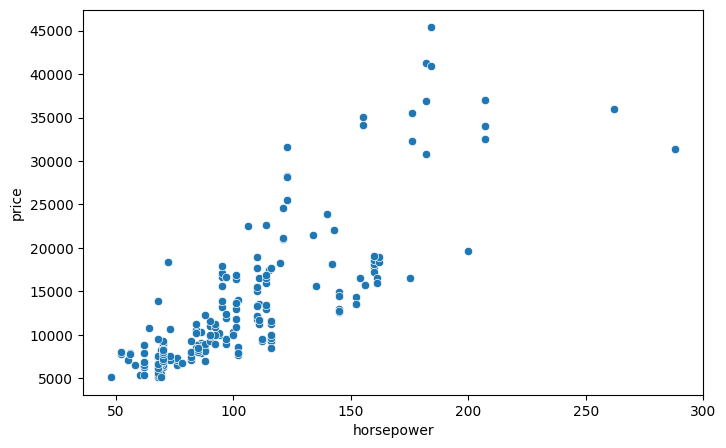

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['horsepower'], y=df['price'])

plt.show()

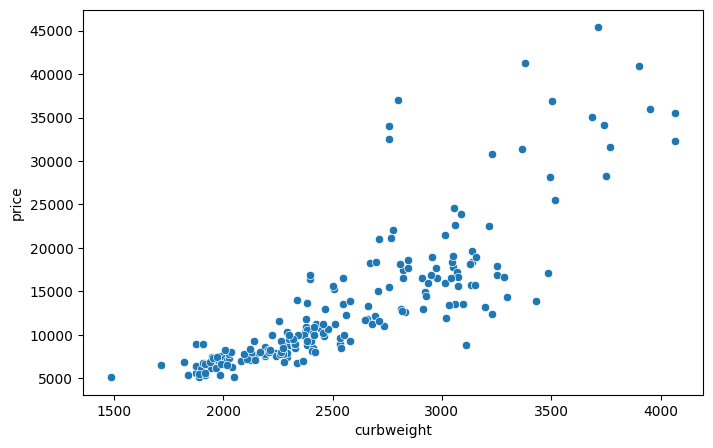

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['curbweight'], y=df['price'])

plt.show()

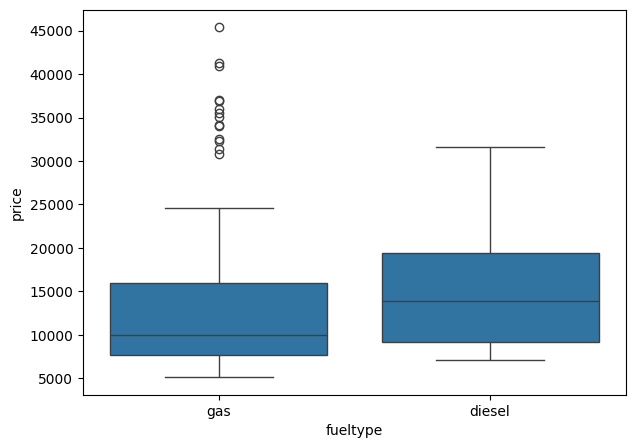

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df['fueltype'], y=df['price'])

plt.show()

In [20]:
df['company'] = df['CarName'].apply(lambda x: x.split(' ')[0])

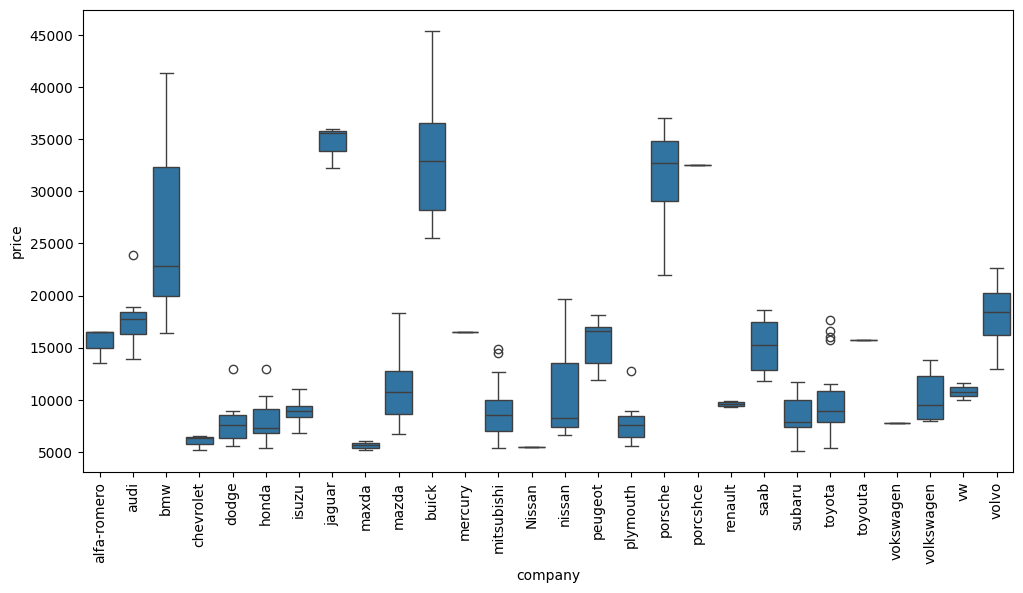

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df['company'], y=df['price'])

plt.xticks(rotation=90)

plt.show()

# Feature Engineering

In [25]:
df['company'] = df['CarName'].apply(lambda x: x.split(' ')[0])

In [26]:
df['company'] = df['company'].replace({
    'maxda':'mazda',
    'toyouta':'toyota',
    'vokswagen':'volkswagen',
    'vw':'volkswagen'
})

# Preprocessing

In [27]:
df.drop(['CarName','car_ID'], axis=1, inplace=True)

In [28]:
df = pd.get_dummies(df, drop_first=True)

In [30]:
df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,company_peugeot,company_plymouth,company_porcshce,company_porsche,company_renault,company_saab,company_subaru,company_toyota,company_volkswagen,company_volvo
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,False,False,False


# Model

In [31]:
y = df['price']

In [32]:
X = df.drop('price', axis=1)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_pred)

1730.4429236968317

In [38]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, y_pred)

6703371.307722349

In [39]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.9150870296061944

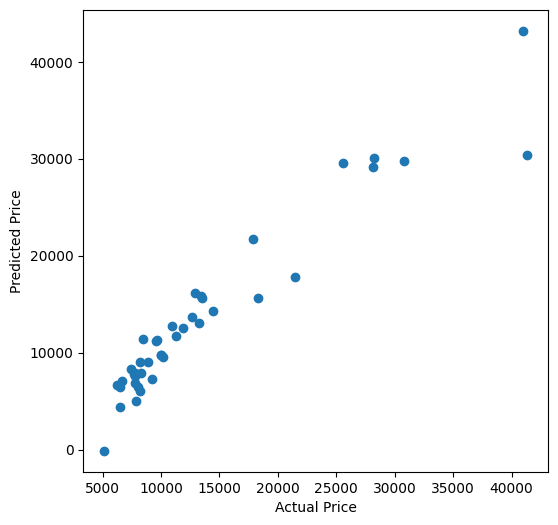

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [41]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
45,company_bmw,8101.943820
23,enginelocation_rear,7589.141094
59,company_porsche,6111.244148
46,company_buick,5810.471817
58,company_porcshce,4133.717487
...,...,...
32,cylindernumber_six,-3951.958261
7,boreratio,-4090.856450
30,cylindernumber_five,-4116.639851
24,enginetype_dohcv,-5040.233164


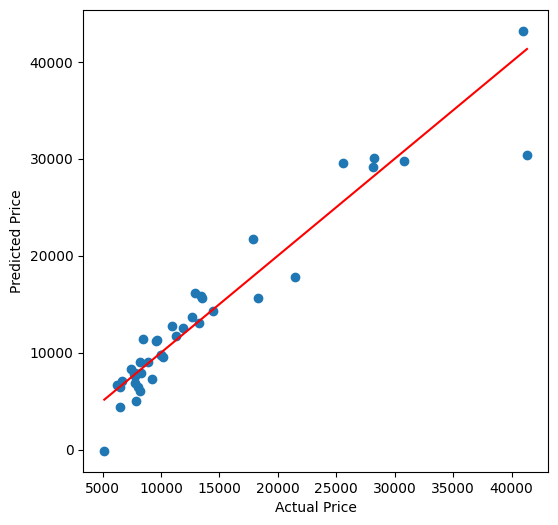

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [43]:
r2_score(y_test, y_pred)

0.9150870296061944

In [44]:
mean_absolute_error(y_test, y_pred)

1730.4429236968317

In [45]:
model.score(X_train, y_train)

model.score(X_test, y_test)

0.9150870296061944